# Checkpoint 2: PR Merge Outcome Modeling

This notebook turns the Checkpoint 1 audit into a reproducible modeling baseline. It keeps the scope deliberately conservative: only PR-level features judged plausibly available before the final merge decision are used, while identifiers, clear post-outcome fields, and unresolved timing-sensitive variables remain excluded.


## Objective and scope

**Research question:** Can PR-level features help explain and predict PR merge outcomes on GitHub?

Checkpoint 2 focuses on the first serious supervised baseline. The provided test split is still reserved for the final evaluation; this notebook uses an internal validation split from the training file.


In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180

RANDOM_STATE = 42
TARGET_COLUMN = "merged_or_not"
TARGET_LABELS = {0: "Not merged", 1: "Merged"}


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "README.md").exists() and (candidate / "data" / "raw").exists():
            return candidate
    fallback = Path("/Users/mahmoudali/Documents/ADES - first project")
    if fallback.exists():
        return fallback
    raise FileNotFoundError("Could not locate the ADES project root.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
CHECKPOINT2_DIR = PROJECT_ROOT / "deliverables" / "checkpoint-2"
FINAL_DIR = PROJECT_ROOT / "deliverables" / "final"
FIGURE_DIR = FINAL_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "prfeatures_train_data.csv"
TEST_PATH = DATA_DIR / "prfeatures_test_data.csv"

exclude_ids = ["id", "project_id", "creator_id", "last_closer_id"]
exclude_post_outcome = ["last_close_time", "lifetime_minutes", "reopen_or_not"]
ambiguous_features = [
    "num_comments", "has_comments", "num_participants", "core_comment",
    "contrib_comment", "inte_comment", "has_exchange", "at_tag",
    "num_code_comments", "num_code_comments_con", "perc_neg_emotion",
    "perc_pos_emotion", "comment_conflict", "contrib_open", "contrib_cons",
    "contrib_extra", "contrib_agree", "contrib_neur", "inte_open",
    "inte_cons", "inte_extra", "inte_agree", "inte_neur",
    "perc_contrib_pos_emo", "perc_contrib_neg_emo", "perc_inte_pos_emo",
    "perc_inte_neg_emo", "social_strength", "same_user", "ci_build_num",
    "ci_failed_perc", "integrator_availability",
]
candidate_safe_features = [
    "first_pr", "prior_review_num", "core_member", "prior_interaction",
    "followers", "prev_pullreqs", "account_creation_days",
    "contrib_perc_commit", "sloc", "team_size", "language",
    "open_issue_num", "project_age", "open_pr_num", "fork_num",
    "pr_succ_rate", "test_lines_per_kloc", "stars",
    "test_cases_per_kloc", "asserts_per_kloc", "perc_external_contribs",
    "requester_succ_rate", "churn_addition", "churn_deletion",
    "description_length", "test_inclusion", "ci_exists", "test_churn",
    "num_commits", "src_churn", "files_changed", "friday_effect",
]
safe_usecols = [TARGET_COLUMN, *candidate_safe_features]

questionable_timing_features = [
    "open_pr_num", "pr_succ_rate", "requester_succ_rate", "test_churn"
]
strict_safe_features = [
    feature for feature in candidate_safe_features
    if feature not in questionable_timing_features
]
strict_safe_usecols = [TARGET_COLUMN, *strict_safe_features]

binary_features = [
    "first_pr", "core_member", "test_inclusion", "ci_exists", "friday_effect"
]
categorical_features = ["language"]
numeric_features = [
    feature for feature in candidate_safe_features
    if feature not in binary_features and feature not in categorical_features
]

safe_feature_timing_reason = {
    "first_pr": "Contributor history flag available before or at PR submission.",
    "prior_review_num": "Contributor/reviewer history count before the current PR outcome.",
    "core_member": "Author role/affiliation metadata available before review outcome.",
    "prior_interaction": "Historical author-integrator interaction count before the current PR outcome.",
    "followers": "Contributor profile context available at PR submission.",
    "prev_pullreqs": "Contributor historical PR count before the current PR outcome.",
    "account_creation_days": "Contributor account age at PR submission.",
    "contrib_perc_commit": "Contributor historical share of project commits before the current PR outcome.",
    "sloc": "Project size snapshot available independently of the current PR closure.",
    "team_size": "Project/team context available before the current PR outcome.",
    "language": "Project language category available before modeling; treated as nominal.",
    "open_issue_num": "Project issue-count snapshot used as pre-outcome project context.",
    "project_age": "Repository age at PR submission.",
    "open_pr_num": "Project open-PR workload snapshot; used only under the assumption it is measured at or before PR submission.",
    "fork_num": "Repository popularity/context snapshot available before the current PR outcome.",
    "pr_succ_rate": "Historical project PR success rate; used only as past project context, not including the current PR outcome.",
    "test_lines_per_kloc": "Project test-density snapshot available before closure.",
    "stars": "Repository popularity snapshot available before the current PR outcome.",
    "test_cases_per_kloc": "Project test-density snapshot available before closure.",
    "asserts_per_kloc": "Project test/assertion-density snapshot available before closure.",
    "perc_external_contribs": "Historical project contributor-mix rate before the current PR outcome.",
    "requester_succ_rate": "Requester historical merge-success rate; used only as past contributor context.",
    "churn_addition": "Initial PR diff size available after submission and before final closure.",
    "churn_deletion": "Initial PR diff size available after submission and before final closure.",
    "description_length": "PR description length available at submission.",
    "test_inclusion": "Initial PR diff/test-inclusion flag available before final closure.",
    "ci_exists": "Repository CI configuration/availability flag, not a CI outcome.",
    "test_churn": "Initial PR diff test-churn measure available before final closure.",
    "num_commits": "Current PR commit count from the submitted diff snapshot; not a closure outcome.",
    "src_churn": "Initial PR source-churn measure available before final closure.",
    "files_changed": "Initial PR diff size available before final closure.",
    "friday_effect": "Submission calendar flag available immediately at PR creation.",
}


def availability_reason(feature_name: str) -> str:
    return safe_feature_timing_reason.get(
        feature_name,
        "Conservative pre-outcome PR-level feature retained for modeling.",
    )


def target_distribution(df: pd.DataFrame, split: str) -> pd.DataFrame:
    counts = df[TARGET_COLUMN].value_counts().sort_index()
    return pd.DataFrame(
        {
            "split": split,
            "target_value": counts.index,
            "label": [TARGET_LABELS[int(value)] for value in counts.index],
            "count": counts.values,
            "percentage": (counts.values / len(df) * 100).round(2),
        }
    )


def stratified_sample(df: pd.DataFrame, n: int, random_state: int = RANDOM_STATE) -> pd.DataFrame:
    if n >= len(df):
        return df.copy()
    _, sample = train_test_split(
        df,
        test_size=n,
        stratify=df[TARGET_COLUMN],
        random_state=random_state,
    )
    return sample.reset_index(drop=True)


def feature_type_groups(feature_list: list[str] | None = None) -> tuple[list[str], list[str], list[str]]:
    selected_features = list(candidate_safe_features if feature_list is None else feature_list)
    selected_binary = [feature for feature in binary_features if feature in selected_features]
    selected_categorical = [feature for feature in categorical_features if feature in selected_features]
    selected_numeric = [
        feature for feature in selected_features
        if feature not in selected_binary and feature not in selected_categorical
    ]
    return selected_numeric, selected_binary, selected_categorical


def make_preprocessor(feature_list: list[str] | None = None) -> ColumnTransformer:
    selected_numeric, selected_binary, selected_categorical = feature_type_groups(feature_list)
    return ColumnTransformer(
        transformers=[
            ("numeric", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), selected_numeric),
            ("binary", SimpleImputer(strategy="most_frequent"), selected_binary),
            ("categorical", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]), selected_categorical),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def build_models(y_train: pd.Series, feature_list: list[str] | None = None) -> dict[str, Pipeline]:
    models: dict[str, Pipeline] = {
        "Dummy majority": Pipeline([
            ("preprocess", make_preprocessor(feature_list)),
            ("model", DummyClassifier(strategy="most_frequent")),
        ]),
        "Logistic regression balanced": Pipeline([
            ("preprocess", make_preprocessor(feature_list)),
            ("model", LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                solver="lbfgs",
                random_state=RANDOM_STATE,
            )),
        ]),
        "Decision tree balanced": Pipeline([
            ("preprocess", make_preprocessor(feature_list)),
            ("model", DecisionTreeClassifier(
                max_depth=10,
                min_samples_leaf=80,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )),
        ]),
        "Random forest balanced": Pipeline([
            ("preprocess", make_preprocessor(feature_list)),
            ("model", RandomForestClassifier(
                n_estimators=80,
                max_depth=14,
                min_samples_leaf=60,
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ]),
        "Hist gradient boosting weighted": Pipeline([
            ("preprocess", make_preprocessor(feature_list)),
            ("model", HistGradientBoostingClassifier(
                max_iter=140,
                max_leaf_nodes=31,
                learning_rate=0.08,
                l2_regularization=0.01,
                random_state=RANDOM_STATE,
            )),
        ]),
    }
    try:
        from xgboost import XGBClassifier

        models["XGBoost weighted"] = Pipeline([
            ("preprocess", make_preprocessor(feature_list)),
            ("model", XGBClassifier(
                n_estimators=120,
                max_depth=4,
                learning_rate=0.08,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                scale_pos_weight=1.0,
            )),
        ])
    except Exception as exc:
        print(f"XGBoost unavailable, skipping optional baseline ({type(exc).__name__}).")
    return models


def score_merged_probability(pipeline: Pipeline, X: pd.DataFrame) -> np.ndarray:
    if hasattr(pipeline, "predict_proba"):
        return pipeline.predict_proba(X)[:, 1]
    elif hasattr(pipeline[-1], "decision_function"):
        decision = pipeline.decision_function(X)
        return 1 / (1 + np.exp(-decision))
    return pipeline.predict(X).astype(float)


def predict_with_not_merged_threshold(
    pipeline: Pipeline,
    X: pd.DataFrame,
    threshold: float,
) -> np.ndarray:
    score_not_merged = 1 - score_merged_probability(pipeline, X)
    return np.where(score_not_merged >= threshold, 0, 1)


def score_predictions(
    name: str,
    y: pd.Series,
    y_pred: np.ndarray,
    y_score_merged: np.ndarray,
    threshold_label: str = "default_model_threshold",
    threshold_value: float | None = None,
) -> dict[str, object]:
    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    try:
        roc_auc = roc_auc_score(y, y_score_merged)
    except ValueError:
        roc_auc = np.nan
    try:
        average_precision_not_merged = average_precision_score(1 - y, 1 - y_score_merged)
    except ValueError:
        average_precision_not_merged = np.nan

    return {
        "model": name,
        "threshold_label": threshold_label,
        "threshold_value": threshold_value,
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "precision_not_merged": precision_score(y, y_pred, pos_label=0, zero_division=0),
        "recall_not_merged": recall_score(y, y_pred, pos_label=0, zero_division=0),
        "f1_not_merged": f1_score(y, y_pred, pos_label=0, zero_division=0),
        "precision_merged": precision_score(y, y_pred, pos_label=1, zero_division=0),
        "recall_merged": recall_score(y, y_pred, pos_label=1, zero_division=0),
        "f1_merged": f1_score(y, y_pred, pos_label=1, zero_division=0),
        "roc_auc_merged": roc_auc,
        "average_precision_not_merged": average_precision_not_merged,
        "tn_not_merged": int(cm[0, 0]),
        "fp_not_merged": int(cm[0, 1]),
        "fn_merged": int(cm[1, 0]),
        "tp_merged": int(cm[1, 1]),
        "actual_not_merged": int(cm[0, :].sum()),
        "predicted_not_merged": int(cm[:, 0].sum()),
        "correct_not_merged": int(cm[0, 0]),
        "missed_not_merged": int(cm[0, 1]),
        "false_not_merged": int(cm[1, 0]),
        "correct_merged": int(cm[1, 1]),
    }


def score_pipeline(
    name: str,
    pipeline: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
    threshold: float | None = None,
    threshold_label: str = "default_model_threshold",
) -> dict[str, object]:
    y_score_merged = score_merged_probability(pipeline, X)
    if threshold is None:
        y_pred = pipeline.predict(X)
        threshold_value = None
    else:
        y_pred = predict_with_not_merged_threshold(pipeline, X, threshold)
        threshold_value = float(threshold)
    return score_predictions(
        name,
        y,
        y_pred,
        y_score_merged,
        threshold_label=threshold_label,
        threshold_value=threshold_value,
    )


def fit_pipeline(name: str, pipeline: Pipeline, X_train: pd.DataFrame, y_train: pd.Series) -> Pipeline:
    fitted_pipeline = clone(pipeline)
    if name in {"XGBoost weighted", "Hist gradient boosting weighted"}:
        sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
        fitted_pipeline.fit(X_train, y_train, model__sample_weight=sample_weight)
    else:
        fitted_pipeline.fit(X_train, y_train)
    return fitted_pipeline


def fit_and_compare(
    train_df: pd.DataFrame,
    model_sample_size: int,
    validation_size: float = 0.25,
    feature_list: list[str] | None = None,
) -> tuple[pd.DataFrame, dict[str, Pipeline], tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]]:
    selected_features = list(candidate_safe_features if feature_list is None else feature_list)
    model_df = stratified_sample(train_df[[TARGET_COLUMN, *selected_features]], model_sample_size)
    X = model_df[selected_features]
    y = model_df[TARGET_COLUMN]
    X_train, X_valid, y_train, y_valid = train_test_split(
        X,
        y,
        test_size=validation_size,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    models = build_models(y_train, selected_features)
    fitted: dict[str, Pipeline] = {}
    rows: list[dict[str, object]] = []

    for name, pipeline in models.items():
        fitted_pipeline = fit_pipeline(name, pipeline, X_train, y_train)
        fitted[name] = fitted_pipeline
        rows.append(score_pipeline(name, fitted_pipeline, X_valid, y_valid))

    comparison = pd.DataFrame(rows).sort_values(
        ["f1_not_merged", "balanced_accuracy", "average_precision_not_merged"],
        ascending=False,
    )
    return comparison.reset_index(drop=True), fitted, (X_train, X_valid, y_train, y_valid)


def threshold_tuning_table(pipeline: Pipeline, X_valid: pd.DataFrame, y_valid: pd.Series) -> pd.DataFrame:
    score_not_merged = 1 - score_merged_probability(pipeline, X_valid)
    precision, recall, thresholds = precision_recall_curve(1 - y_valid, score_not_merged)
    table = pd.DataFrame(
        {
            "threshold": thresholds,
            "precision_not_merged": precision[:-1],
            "recall_not_merged": recall[:-1],
        }
    )
    table["f1_not_merged"] = (
        2 * table["precision_not_merged"] * table["recall_not_merged"]
        / (table["precision_not_merged"] + table["recall_not_merged"]).replace(0, np.nan)
    ).fillna(0)
    table = table.sort_values(
        ["f1_not_merged", "recall_not_merged", "precision_not_merged"],
        ascending=[False, False, False],
    )
    return table.reset_index(drop=True)


def repeated_validation_summary(
    train_df: pd.DataFrame,
    model_sample_size: int,
    feature_list: list[str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    selected_features = list(candidate_safe_features if feature_list is None else feature_list)
    cv_df = stratified_sample(train_df[[TARGET_COLUMN, *selected_features]], model_sample_size)
    X = cv_df[selected_features]
    y = cv_df[TARGET_COLUMN]
    splitter = RepeatedStratifiedKFold(n_splits=3, n_repeats=2, random_state=RANDOM_STATE)
    rows: list[dict[str, object]] = []
    for fold_number, (train_idx, valid_idx) in enumerate(splitter.split(X, y), start=1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        for name, pipeline in build_models(y_train, selected_features).items():
            fitted_pipeline = fit_pipeline(name, pipeline, X_train, y_train)
            row = score_pipeline(name, fitted_pipeline, X_valid, y_valid)
            row["fold"] = fold_number
            rows.append(row)
    fold_scores = pd.DataFrame(rows)
    metric_columns = [
        "accuracy", "balanced_accuracy", "precision_not_merged",
        "recall_not_merged", "f1_not_merged", "roc_auc_merged",
        "average_precision_not_merged",
    ]
    summary = (
        fold_scores.groupby("model")[metric_columns]
        .agg(["mean", "std"])
        .reset_index()
    )
    summary.columns = [
        column[0] if column[1] == "" else f"{column[0]}_{column[1]}"
        for column in summary.columns.to_flat_index()
    ]
    summary = summary.sort_values(
        [
            "f1_not_merged_mean",
            "balanced_accuracy_mean",
            "average_precision_not_merged_mean",
        ],
        ascending=False,
    ).reset_index(drop=True)
    summary.insert(1, "cv_folds", 6)
    summary.insert(2, "model_sample_size", len(cv_df))
    return summary, fold_scores


def bootstrap_metric_intervals(
    y_true: pd.Series,
    y_pred: np.ndarray,
    y_score_merged: np.ndarray,
    threshold_label: str,
    n_resamples: int = 500,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)
    y_score_array = np.asarray(y_score_merged)
    metric_rows: list[dict[str, float | str]] = []
    samples: dict[str, list[float]] = {
        "precision_not_merged": [],
        "recall_not_merged": [],
        "f1_not_merged": [],
        "balanced_accuracy": [],
        "roc_auc_merged": [],
    }
    for _ in range(n_resamples):
        indices = rng.integers(0, len(y_true_array), len(y_true_array))
        y_boot = y_true_array[indices]
        pred_boot = y_pred_array[indices]
        score_boot = y_score_array[indices]
        samples["precision_not_merged"].append(precision_score(y_boot, pred_boot, pos_label=0, zero_division=0))
        samples["recall_not_merged"].append(recall_score(y_boot, pred_boot, pos_label=0, zero_division=0))
        samples["f1_not_merged"].append(f1_score(y_boot, pred_boot, pos_label=0, zero_division=0))
        samples["balanced_accuracy"].append(balanced_accuracy_score(y_boot, pred_boot))
        if len(np.unique(y_boot)) == 2:
            samples["roc_auc_merged"].append(roc_auc_score(y_boot, score_boot))
    for metric, values in samples.items():
        clean_values = np.asarray([value for value in values if not pd.isna(value)])
        metric_rows.append(
            {
                "threshold_label": threshold_label,
                "metric": metric,
                "estimate": float(np.mean(clean_values)),
                "ci_lower_95": float(np.quantile(clean_values, 0.025)),
                "ci_upper_95": float(np.quantile(clean_values, 0.975)),
                "bootstrap_resamples": n_resamples,
            }
        )
    return pd.DataFrame(metric_rows)


def feature_names_from_pipeline(pipeline: Pipeline) -> np.ndarray:
    preprocessor = pipeline.named_steps["preprocess"]
    return preprocessor.get_feature_names_out()


def feature_importance_table(pipeline: Pipeline) -> pd.DataFrame:
    model = pipeline.named_steps["model"]
    names = feature_names_from_pipeline(pipeline)
    if hasattr(model, "feature_importances_"):
        values = model.feature_importances_
    elif hasattr(model, "coef_"):
        values = np.abs(model.coef_[0])
    else:
        return pd.DataFrame(columns=["feature", "importance"])
    return (
        pd.DataFrame({"feature": names, "importance": values})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


In [2]:
print(f"Project root: {PROJECT_ROOT}")
print(f"Train path exists: {TRAIN_PATH.exists()}")
print(f"Test path exists: {TEST_PATH.exists()}")


Project root: /Users/mahmoudali/Documents/ADES - first project
Train path exists: True
Test path exists: True


## Leakage-aware feature set

The model uses 32 conservative candidate-safe features. `language` is treated as a categorical code, not a rank. Review/process variables whose timing is unclear stay out of this checkpoint model.


In [3]:
feature_groups = pd.DataFrame(
    [
        {"group": "Identifiers", "count": len(exclude_ids), "use": "Excluded"},
        {"group": "Post-outcome leakage", "count": len(exclude_post_outcome), "use": "Excluded"},
        {"group": "Timing-sensitive under review", "count": len(ambiguous_features), "use": "Held back"},
        {"group": "Conservative modeling features", "count": len(candidate_safe_features), "use": "Used now"},
    ]
)
safe_feature_table = pd.DataFrame(
    {
        "feature": candidate_safe_features,
        "availability_rationale": [availability_reason(feature) for feature in candidate_safe_features],
    }
)
display(feature_groups)
display(safe_feature_table)


,group,count,use
0,Identifiers,4,Excluded
1,Post-outcome leakage,3,Excluded
2,Timing-sensitive under review,32,Held back
3,Conservative modeling features,32,Used now


,feature,availability_rationale
0,first_pr,Contributor history flag available before or a...
1,prior_review_num,Contributor/reviewer history count before the ...
2,core_member,Author role/affiliation metadata available bef...
3,prior_interaction,Historical author-integrator interaction count...
4,followers,Contributor profile context available at PR su...
5,prev_pullreqs,Contributor historical PR count before the cur...
6,account_creation_days,Contributor account age at PR submission.
7,contrib_perc_commit,Contributor historical share of project commit...
8,sloc,Project size snapshot available independently ...
9,team_size,Project/team context available before the curr...


## Load the training split and audit the target


In [4]:
train_df = pd.read_csv(TRAIN_PATH, usecols=safe_usecols, low_memory=False)
test_header = pd.read_csv(TEST_PATH, nrows=0)

audit_summary = pd.DataFrame(
    [
        {"check": "training rows loaded", "result": f"{len(train_df):,}"},
        {"check": "safe feature columns", "result": len(candidate_safe_features)},
        {"check": "target present", "result": TARGET_COLUMN in train_df.columns},
        {"check": "explicit nulls in modeling frame", "result": int(train_df.isna().sum().sum())},
        {"check": "duplicate rows in modeling frame", "result": int(train_df.duplicated().sum())},
        {"check": "test schema contains target", "result": TARGET_COLUMN in test_header.columns},
    ]
)
display(audit_summary)
display(target_distribution(train_df, "train"))


,check,result
0,training rows loaded,"1,045,883"
1,safe feature columns,32
2,target present,True
3,explicit nulls in modeling frame,0
4,duplicate rows in modeling frame,1
5,test schema contains target,True


,split,target_value,label,count,percentage
0,train,0,Not merged,113345,10.8400
1,train,1,Merged,932538,89.1600


## Baseline model comparison


XGBoost unavailable, skipping optional baseline (XGBoostError).


,model,threshold_label,threshold_value,accuracy,balanced_accuracy,precision_not_merged,recall_not_merged,f1_not_merged,precision_merged,recall_merged,f1_merged,roc_auc_merged,average_precision_not_merged,tn_not_merged,fp_not_merged,fn_merged,tp_merged,actual_not_merged,predicted_not_merged,correct_not_merged,missed_not_merged,false_not_merged,correct_merged
0,Random forest balanced,default_model_threshold,None,0.8142,0.7031,0.3056,0.5613,0.3957,0.9406,0.8450,0.8902,0.7775,0.3942,3346,2615,7603,41436,5961,10949,3346,2615,7603,41436
1,Hist gradient boosting weighted,default_model_threshold,None,0.7814,0.7122,0.2755,0.6239,0.3822,0.9460,0.8006,0.8672,0.7792,0.4048,3719,2242,9780,39259,5961,13499,3719,2242,9780,39259
2,Decision tree balanced,default_model_threshold,None,0.7467,0.6617,0.2264,0.5531,0.3213,0.9341,0.7702,0.8443,0.7199,0.3347,3297,2664,11267,37772,5961,14564,3297,2664,11267,37772
3,Logistic regression balanced,default_model_threshold,None,0.6381,0.6266,0.1718,0.6120,0.2682,0.9315,0.6413,0.7596,0.6713,0.2133,3648,2313,17592,31447,5961,21240,3648,2313,17592,31447
4,Dummy majority,default_model_threshold,None,0.8916,0.5000,0.0000,0.0000,0.0000,0.8916,1.0000,0.9427,0.5000,0.1084,0,5961,0,49039,5961,0,0,5961,0,49039


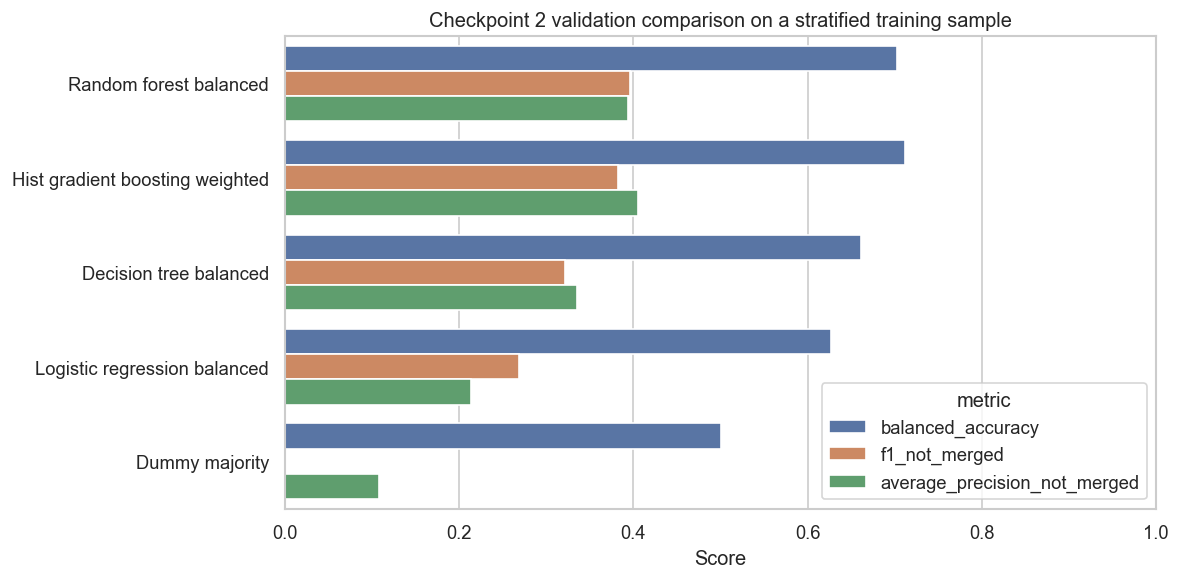

In [5]:
MODEL_SAMPLE_SIZE = 220_000
comparison, fitted_models, validation_data = fit_and_compare(train_df, MODEL_SAMPLE_SIZE)
display(comparison)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = comparison.melt(
    id_vars="model",
    value_vars=["balanced_accuracy", "f1_not_merged", "average_precision_not_merged"],
    var_name="metric",
    value_name="score",
)
sns.barplot(data=plot_df, x="score", y="model", hue="metric", ax=ax)
ax.set_title("Checkpoint 2 validation comparison on a stratified training sample")
ax.set_xlim(0, 1)
ax.set_xlabel("Score")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## Interpretation for Checkpoint 2

The dummy classifier is expected to look deceptively strong on raw accuracy because merged PRs dominate the dataset. For grading and scientific credibility, the minority-class metrics are more informative: recall and F1 for not-merged PRs, balanced accuracy, and average precision for the not-merged class.


In [6]:
best_row = comparison.iloc[0]
display(Markdown(f'''
**Checkpoint 2 finding.** The strongest validation baseline by not-merged F1 is **{best_row["model"]}**.

- Not-merged F1: `{best_row["f1_not_merged"]:.3f}`
- Not-merged recall: `{best_row["recall_not_merged"]:.3f}`
- Balanced accuracy: `{best_row["balanced_accuracy"]:.3f}`
- Not-merged average precision: `{best_row["average_precision_not_merged"]:.3f}`

The next checkpoint should lock the final feature set, run the selected model against the untouched test split, and add one unsupervised analysis that profiles PR groups without using the target during clustering.
'''))



**Checkpoint 2 finding.** The strongest validation baseline by not-merged F1 is **Random forest balanced**.

- Not-merged F1: `0.396`
- Not-merged recall: `0.561`
- Balanced accuracy: `0.703`
- Not-merged average precision: `0.394`

The next checkpoint should lock the final feature set, run the selected model against the untouched test split, and add one unsupervised analysis that profiles PR groups without using the target during clustering.


## Checkpoint 2 limitations

- This is a validation baseline, not the final model.
- The provided test split is intentionally not used here.
- Timing-sensitive discussion, CI, and sentiment fields are still held back until their availability at prediction time can be defended.
- The baseline uses a stratified sample for runtime; the final notebook should report the sample size and evaluate on the full provided test split.
